In [1]:
!pip install catboost

### 1. Importing Necessary Library

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
from math import radians, sin, cos, sqrt, asin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import xgboost as xg
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,ExtraTreesRegressor,VotingRegressor
from sklearn.tree import DecisionTreeRegressor
from lightgbm.sklearn import LGBMRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

### 2. Data Understanding

Defines clean_delivery_data(df) to perform initial data cleaning:

- Strips whitespace from ID columns.

- Extracts numeric value from Time_taken(min) (removes any non‑numeric characters).

- Cleans the Weatherconditions column by removing the prefix "conditions ".

- Replaces string 'NaN ' with actual NaN.

- Converts columns like Delivery_person_Age, Ratings, etc., to numeric.

- Sets latitude/longitude values of 0 to NaN (invalid coordinates).



In [3]:
def clean_delivery_data(df):
    """
    Basic cleaning operations for the delivery dataset

    Parameters:
    df: DataFrame to clean

    Returns:
    Cleaned DataFrame
    """
    # Make a copy to avoid modifying original
    df = df.copy()

    # Clean ID columns
    if 'ID' in df.columns:
        df['ID'] = df['ID'].str.strip()

    if 'Delivery_person_ID' in df.columns:
        df['Delivery_person_ID'] = df['Delivery_person_ID'].str.strip()

    # Clean Time_taken column - extract numeric value
    if 'Time_taken(min)' in df.columns:
        df['Time_taken(min)'] = df['Time_taken(min)'].astype(str).str.extract(r'(\d+)').astype(float)

    # Clean Weatherconditions
    if 'Weatherconditions' in df.columns:
        df['Weatherconditions'] = df['Weatherconditions'].astype(str).str.replace('conditions ', '', regex=False)

    # Clean Road_traffic_density
    if 'Road_traffic_density' in df.columns:
        df['Road_traffic_density'] = df['Road_traffic_density'].astype(str).str.strip()

    # Replace 'NaN ' strings with actual NaN
    df = df.replace('NaN ', np.nan)
    df = df.replace('NaN', np.nan)

    # Convert numeric columns
    numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings',
                    'Vehicle_condition', 'multiple_deliveries']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Fix latitude/longitude issues (mark zeros as invalid)
    location_cols = ['Restaurant_latitude', 'Restaurant_longitude',
                     'Delivery_location_latitude', 'Delivery_location_longitude']
    for col in location_cols:
        if col in df.columns:
            df.loc[df[col] == 0, col] = np.nan

    return df


Converts Order_Date to datetime.

- Creates new columns: Year, Month, Day, DayOfWeek, IsWeekend, and DayName.
- These features help capture seasonal and weekly patterns in delivery times.



In [4]:

def extract_date_features(df):
    """
    Extract features from Order_Date column

    Parameters:
    df: DataFrame with Order_Date column

    Returns:
    DataFrame with date features
    """
    df = df.copy()

    if 'Order_Date' in df.columns:
        # Convert to datetime
        df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')

        # Extract date components
        df['Year'] = df['Order_Date'].dt.year
        df['Month'] = df['Order_Date'].dt.month
        df['Day'] = df['Order_Date'].dt.day
        df['DayOfWeek'] = df['Order_Date'].dt.dayofweek
        df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

        # Day name for reference
        day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
                   4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
        df['DayName'] = df['DayOfWeek'].map(day_map)

    return df


Defines extract_time_features(df) to process the time columns Time_Orderd and Time_Order_picked:

- Parses time strings into time objects.

- Extracts hour and categorises into Morning, Afternoon, Evening, Night.

- Computes Time_to_assign = (pickup time – order time) in minutes, handling cases where pickup occurs after midnight.



In [5]:
def extract_time_features(df):
    """
    Extract features from time columns

    Parameters:
    df: DataFrame with Time_Orderd and Time_Order_picked columns

    Returns:
    DataFrame with time features
    """
    df = df.copy()

    def parse_time(time_str):
        """Helper function to parse time strings"""
        try:
            if pd.isna(time_str) or time_str == 'NaN ':
                return np.nan
            return pd.to_datetime(time_str, format='%H:%M:%S').time()
        except:
            return np.nan

    def time_diff(order_time, picked_time):
        """Calculate time difference in minutes"""
        if pd.isna(order_time) or pd.isna(picked_time):
            return np.nan
        try:
            order = datetime.combine(datetime.today(), order_time)
            picked = datetime.combine(datetime.today(), picked_time)
            diff = (picked - order).total_seconds() / 60
            if diff < 0:  # Handle cases where pickup is on next day
                diff += 24 * 60
            return diff
        except:
            return np.nan

    def get_hour(time_obj):
        """Extract hour from time object"""
        if pd.isna(time_obj):
            return np.nan
        return time_obj.hour

    def get_time_category(hour):
        """Categorize time of day"""
        if pd.isna(hour):
            return np.nan
        if 5 <= hour < 12:
            return 'Morning'
        elif 12 <= hour < 17:
            return 'Afternoon'
        elif 17 <= hour < 21:
            return 'Evening'
        else:
            return 'Night'

    if 'Time_Orderd' in df.columns:
        df['Time_Orderd'] = df['Time_Orderd'].apply(parse_time)
        df['Order_Hour'] = df['Time_Orderd'].apply(get_hour)
        df['Order_Time_Category'] = df['Order_Hour'].apply(get_time_category)

    if 'Time_Order_picked' in df.columns:
        df['Time_Order_picked'] = df['Time_Order_picked'].apply(parse_time)
        df['Pickup_Hour'] = df['Time_Order_picked'].apply(get_hour)
        df['Pickup_Time_Category'] = df['Pickup_Hour'].apply(get_time_category)

    # Calculate time to assign if both times are available
    if 'Time_Orderd' in df.columns and 'Time_Order_picked' in df.columns:
        df['Time_to_assign'] = df.apply(
            lambda x: time_diff(x['Time_Orderd'], x['Time_Order_picked']), axis=1
        )

    return df


Defines calculate_distance(df) which uses the haversine formula to compute the great‑circle distance (in km) between the restaurant’s coordinates and the delivery location. The result is stored in a new column Distance_km. Missing coordinates are handled gracefully.

In [6]:

def calculate_distance(df):
    """
    Calculate haversine distance between restaurant and delivery location

    Parameters:
    df: DataFrame with latitude/longitude columns

    Returns:
    DataFrame with distance column
    """
    df = df.copy()

    def haversine(lat1, lon1, lat2, lon2):
        """Calculate great-circle distance between two points"""
        if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
            return np.nan

        R = 6371  # Earth's radius in km

        try:
            lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
            dlat = lat2 - lat1
            dlon = lon2 - lon1

            a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
            c = 2 * np.arcsin(np.sqrt(a))

            return R * c
        except:
            return np.nan

    required_cols = ['Restaurant_latitude', 'Restaurant_longitude',
                     'Delivery_location_latitude', 'Delivery_location_longitude']

    if all(col in df.columns for col in required_cols):
        df['Distance_km'] = df.apply(
            lambda x: haversine(
                x['Restaurant_latitude'], x['Restaurant_longitude'],
                x['Delivery_location_latitude'], x['Delivery_location_longitude']
            ), axis=1
        )

    return df


Defines extract_id_features(df) to parse Delivery_person_ID:

- Extracts the city code (e.g., "BANGLORE" → "BANGLORE").

- Extracts the person number (digits after RES).
These can be useful for capturing driver‑specific effects.

In [7]:

def extract_id_features(df):
    """
    Extract features from Delivery_person_ID

    Parameters:
    df: DataFrame with Delivery_person_ID column

    Returns:
    DataFrame with extracted ID features
    """
    df = df.copy()

    if 'Delivery_person_ID' in df.columns:
        # Extract city code
        df['Delivery_city'] = df['Delivery_person_ID'].astype(str).str.extract(r'([A-Z]+)')

        # Extract person number
        df['Delivery_person_num'] = df['Delivery_person_ID'].astype(str).str.extract(r'RES(\d+)')
        df['Delivery_person_num'] = pd.to_numeric(df['Delivery_person_num'], errors='coerce')

    return df


Defines create_interaction_features(df) to generate additional features:

- Age groups, rating groups, distance groups (categorical bins).

- Interaction features like Age_Rating_Interaction (product of age and rating) and Distance_Vehicle_Interaction (distance × vehicle condition).
Note: The commented‑out speed feature was removed because it would leak the target variable (Time_taken(min)).

In [8]:
def create_interaction_features(df):
    """
    Create interaction features from existing columns

    Parameters:
    df: DataFrame with base features

    Returns:
    DataFrame with interaction features
    """
    df = df.copy()

    # Speed feature (if both distance and time are available) - REMOVED due to target leakage
    # if 'Distance_km' in df.columns and 'Time_taken(min)' in df.columns:
    #     df['Speed_kmph'] = df['Distance_km'] / (df['Time_taken(min)'] / 60)
    #     # Handle infinite values
    #     df['Speed_kmph'] = df['Speed_kmph'].replace([np.inf, -np.inf], np.nan)

    # Age groups
    if 'Delivery_person_Age' in df.columns:
        df['Age_Group'] = pd.cut(
            df['Delivery_person_Age'],
            bins=[0, 25, 35, 45, 100],
            labels=['Young', 'Middle', 'Senior', 'Very Senior']
        )

    # Rating groups
    if 'Delivery_person_Ratings' in df.columns:
        df['Rating_Group'] = pd.cut(
            df['Delivery_person_Ratings'],
            bins=[0, 4.0, 4.5, 4.8, 5.0],
            labels=['Low', 'Medium', 'High', 'Very High']
        )

    # Distance groups
    if 'Distance_km' in df.columns:
        df['Distance_Group'] = pd.cut(
            df['Distance_km'],
            bins=[0, 5, 10, 15, 20, 50],
            labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
        )

    # Interaction features
    if 'Delivery_person_Age' in df.columns and 'Delivery_person_Ratings' in df.columns:
        df['Age_Rating_Interaction'] = df['Delivery_person_Age'] * df['Delivery_person_Ratings']

    if 'Distance_km' in df.columns and 'Vehicle_condition' in df.columns:
        df['Distance_Vehicle_Interaction'] = df['Distance_km'] * (df['Vehicle_condition'].fillna(1) + 1)

    return df

Defines encode_categorical_features() to label‑encode all categorical columns (e.g., weather, traffic, vehicle type, etc.).

- For training data (fit_encoders=True), it fits a new LabelEncoder for each column and stores them in a dictionary.

- For test data, it uses the previously fitted encoders. Any unseen category is mapped to 'Unknown' (which is added to the encoder’s classes) to avoid errors.



In [9]:
def encode_categorical_features(df, fit_encoders=True, encoders=None):
    """
    Encode categorical features using LabelEncoder

    Parameters:
    df: DataFrame with categorical features
    fit_encoders: Whether to fit new encoders (True for train, False for test)
    encoders: Dictionary of fitted encoders (required when fit_encoders=False)

    Returns:
    DataFrame with encoded features and encoders dictionary
    """
    df = df.copy()

    categorical_cols = [
        'Weatherconditions', 'Road_traffic_density', 'Type_of_order',
        'Type_of_vehicle', 'Festival', 'City', 'Delivery_city',
        'Order_Time_Category', 'Pickup_Time_Category', 'Age_Group',
        'Rating_Group', 'Distance_Group', 'DayName'
    ]

    # Filter to only columns that exist in dataframe
    cols_to_encode = [col for col in categorical_cols if col in df.columns]

    if fit_encoders:
        encoders = {}
        for col in cols_to_encode:
            # Convert to object type before filling NaN to allow new string values
            # This handles cases where columns might be Categorical from pd.cut
            df[col] = df[col].astype(object).fillna('Unknown')
            le = LabelEncoder()
            # Fit and transform on the string representation of the column
            df[col + '_Encoded'] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
        return df, encoders
    else:
        if encoders is None:
            raise ValueError("encoders dictionary must be provided when fit_encoders=False")

        for col in cols_to_encode:
            if col in encoders:
                # Convert to object type before filling NaN
                df[col] = df[col].astype(object).fillna('Unknown')

                # Get existing classes from the fitted encoder
                le = encoders[col]
                known_classes = set(le.classes_)

                # Ensure 'Unknown' is in the encoder's classes before transformation
                if 'Unknown' not in known_classes:
                    # Append 'Unknown' to the encoder's classes.
                    # This is a direct modification of LabelEncoder's internal state.
                    le.classes_ = np.append(le.classes_, 'Unknown')
                    known_classes.add('Unknown') # Update known_classes set for the next step

                # Map values that are not in the (potentially updated) known_classes to 'Unknown'
                # Ensure the column is string type for consistent comparison and application
                df[col + '_Processed'] = df[col].astype(str).apply(
                    lambda x: x if x in known_classes else 'Unknown'
                )
                # Now transform the processed column
                df[col + '_Encoded'] = le.transform(df[col + '_Processed'])
                df = df.drop(columns=[col + '_Processed']) # Drop the temporary column

        return df, encoders

This is the master preprocessing pipeline. It reads the CSV and sequentially applies all the previously defined functions:

- clean_delivery_data

- extract_date_features

- extract_time_features

- calculate_distance

- extract_id_features

- create_interaction_features

- encode_categorical_features (with the appropriate fit_encoders flag)

If is_train=True, it returns the processed DataFrame and the fitted encoders. If is_train=False, it returns only the DataFrame (using the supplied encoders). Progress messages are printed.

In [10]:

def process_delivery_data(file_path, is_train=True, encoders=None):
    """
    Main function to process delivery data

    Parameters:
    file_path: Path to the CSV file
    is_train: Whether this is training data (True) or test data (False)
    encoders: Dictionary of fitted encoders (required for test data)

    Returns:
    Processed DataFrame and encoders (for train) or just DataFrame (for test)
    """
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(file_path)
    print(f"Initial shape: {df.shape}")

    # Step 1: Basic cleaning
    print("Step 1: Performing basic cleaning...")
    df = clean_delivery_data(df)

    # Step 2: Extract date features
    print("Step 2: Extracting date features...")
    df = extract_date_features(df)

    # Step 3: Extract time features
    print("Step 3: Extracting time features...")
    df = extract_time_features(df)

    # Step 4: Calculate distance
    print("Step 4: Calculating distance...")
    df = calculate_distance(df)

    # Step 5: Extract ID features
    print("Step 5: Extracting ID features...")
    df = extract_id_features(df)

    # Step 6: Create interaction features
    print("Step 6: Creating interaction features...")
    df = create_interaction_features(df)

    # Step 7: Encode categorical features
    print("Step 7: Encoding categorical features...")
    if is_train:
        df, encoders = encode_categorical_features(df, fit_encoders=True)
    else:
        df, encoders = encode_categorical_features(df, fit_encoders=False, encoders=encoders)

    print(f"Final shape: {df.shape}")
    print(f"Total features: {len(df.columns)}")

    if is_train:
        return df, encoders
    else:
        return df


Defines get_feature_columns() to return a list of numeric columns that should be used as features. It excludes:

- Identifier columns (ID, Delivery_person_ID)

- Original date/time columns (Order_Date, Time_Orderd, Time_Order_picked, DayName)

- The target variable Time_taken(min) if exclude_target=True



In [11]:


def get_feature_columns(df, exclude_target=True):
    """
    Get list of feature columns (excluding target and ID columns)

    Parameters:
    df: Processed DataFrame
    exclude_target: Whether to exclude target column

    Returns:
    List of feature column names
    """
    # Columns to exclude from features
    exclude_cols = ['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd',
                    'Time_Order_picked', 'DayName']

    if exclude_target and 'Time_taken(min)' in df.columns:
        exclude_cols.append('Time_taken(min)')

    # Get all numeric columns that aren't in exclude list
    feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                    if col not in exclude_cols]

    return feature_cols



- Loads and processes the training data using process_delivery_data.

- Defines the feature matrix X and target vector y.

- Uses SimpleImputer with mean strategy to fill missing values in X (the imputer is fitted on the whole dataset – note: this is done before splitting, which is acceptable here because the split is sequential and we are not leaking future information into the imputation).

- Splits the data into training (first 80%) and testing (last 20%). This is a sequential split (not random), which is appropriate for time‑ordered data.

- A warning is shown that the column Time_to_assign has no observed values – it is entirely missing, so the imputer skips it.

In [12]:
from sklearn.impute import SimpleImputer

train_df, encoders = process_delivery_data('train.csv', is_train=True)

feature_cols = get_feature_columns(train_df)

X = train_df[feature_cols]
y = train_df['Time_taken(min)']

# Impute missing values in X before splitting
imputer = SimpleImputer(strategy='mean')
X_imputed_array = imputer.fit_transform(X)
# Get the feature names that the imputer actually processed and outputted
imputed_feature_names = imputer.get_feature_names_out(input_features=X.columns)
X_imputed = pd.DataFrame(X_imputed_array, columns=imputed_feature_names, index=X.index)

# Define split index
split_idx = int(len(X_imputed) * 0.8)

# Proper train-test split
X_train = X_imputed.iloc[:split_idx].copy()
X_test = X_imputed.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

Loading data from train.csv...
Initial shape: (45593, 20)
Step 1: Performing basic cleaning...
Step 2: Extracting date features...
Step 3: Extracting time features...
Step 4: Calculating distance...
Step 5: Extracting ID features...
Step 6: Creating interaction features...
Step 7: Encoding categorical features...
Final shape: (45593, 52)
Total features: 52


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Time_to_assign']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


### 5. ML Model Building

Defines two helper functions:

- model_eval(model): Makes predictions on the training and test sets, then prints and returns a list of eight metrics: R² train/test, RSS train/test, MSE train/test, RMSE train/test.

- store_model_metrics(model_name, metric_list): Stores these metrics in a global dictionary all_model_metrics for later comparison.

In [13]:
def model_eval(model):

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metric = []
    r2_train_lr = r2_score(y_train, y_pred_train)
    print("R2 score for train:", r2_train_lr)
    metric.append(r2_train_lr)

    r2_test_lr = r2_score(y_test, y_pred_test)
    print("R2 score for test:", r2_test_lr)
    metric.append(r2_test_lr)
    print("--"*20)

    rss1_lr = np.sum(np.square(y_train - y_pred_train))
    print("RSS for train:", rss1_lr)
    metric.append(rss1_lr)

    rss2_lr = np.sum(np.square(y_test - y_pred_test))
    print("RSS for test:", rss2_lr)
    metric.append(rss2_lr)
    print("--"*20)

    mse_train_lr = mean_squared_error(y_train, y_pred_train)
    print("MSE for train:", mse_train_lr)
    metric.append(mse_train_lr)

    mse_test_lr = mean_squared_error(y_test, y_pred_test)
    print("MSE for test:", mse_test_lr)
    metric.append(mse_test_lr)
    print("--"*20)

    rmse_train_lr = mse_train_lr**0.5
    print("RMSE for train:", rmse_train_lr)
    metric.append(rmse_train_lr)

    rmse_test_lr = mse_test_lr**0.5
    print("RMSE for test:", rmse_test_lr)
    metric.append(rmse_test_lr)
    print("--"*20)

    return metric, y_pred_train, y_pred_test

all_model_metrics = {}

def store_model_metrics(model_name, metric_list):
    all_model_metrics[model_name] = {
        'R2_Train': metric_list[0],
        'R2_Test': metric_list[1],
        'RSS_Train': metric_list[2],
        'RSS_Test': metric_list[3],
        'MSE_Train': metric_list[4],
        'MSE_Test': metric_list[5],
        'RMSE_Train': metric_list[6],
        'RMSE_Test': metric_list[7]
    }
    return all_model_metrics[model_name]

1. LinearRegression

Sub‑header for the first model: Linear Regression.

In [14]:
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

Creates and trains a simple Linear Regression model on the training data. The output shows the fitted model object.



In [15]:
metric_lr, y_pred_train, y_pred_test = model_eval(reg)
store_model_metrics('Linear Regression', metric_lr)

R2 score for train: 0.493206744757432
R2 score for test: 0.49280080356370126
----------------------------------------
RSS for train: 1621879.1059963976
RSS for test: 413004.3777992489
----------------------------------------
MSE for train: 44.46671892296972
MSE for test: 45.29053380844927
----------------------------------------
RMSE for train: 6.668337043294207
RMSE for test: 6.729824203383716
----------------------------------------


{'R2_Train': 0.493206744757432,
 'R2_Test': 0.49280080356370126,
 'RSS_Train': np.float64(1621879.1059963976),
 'RSS_Test': np.float64(413004.3777992489),
 'MSE_Train': 44.46671892296972,
 'MSE_Test': 45.29053380844927,
 'RMSE_Train': 6.668337043294207,
 'RMSE_Test': 6.729824203383716}

2. XGBRegressor

Sub‑header for XGBoost regression.

Creates and trains an XGBoost regressor with 500 trees, learning rate 0.05, max depth 6. The output shows the model parameters.

In [16]:
xgb_r = xg.XGBRegressor( n_estimators=500,learning_rate=0.05,max_depth=6,random_state=42)
xgb_r.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

Explanation:
Evaluates the XGBoost model. The results show a much higher R² (train ~0.87, test ~0.82) and lower RMSE compared to linear regression, indicating better performance.



In [17]:
metric_xgb, y_pred_train, y_pred_test = model_eval(xgb_r)
store_model_metrics('XGBoost', metric_xgb)

R2 score for train: 0.8666332960461742
R2 score for test: 0.8245917233755191
----------------------------------------
RSS for train: 426810.4761472934
RSS for test: 142832.21790796123
----------------------------------------
MSE for train: 11.701773212351084
MSE for test: 15.663144852282183
----------------------------------------
RMSE for train: 3.4207854671626343
RMSE for test: 3.9576691185952098
----------------------------------------


{'R2_Train': 0.8666332960461742,
 'R2_Test': 0.8245917233755191,
 'RSS_Train': np.float64(426810.4761472934),
 'RSS_Test': np.float64(142832.21790796123),
 'MSE_Train': 11.701773212351084,
 'MSE_Test': 15.663144852282183,
 'RMSE_Train': 3.4207854671626343,
 'RMSE_Test': 3.9576691185952098}

3. Lasso

Sub‑header for Lasso regression (L1 regularized linear model).

In [18]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

Lasso(alpha=0.01)

Evaluates the Lasso model. Its performance is very similar to linear regression (R² ~0.49), as expected for a small alpha.

In [19]:
metric_lasso, y_pred_train, y_pred_test = model_eval(lasso)
store_model_metrics('Lasso', metric_lasso)

R2 score for train: 0.49307543002201204
R2 score for test: 0.4925921140282554
----------------------------------------
RSS for train: 1622299.3496035961
RSS for test: 413174.310426007
----------------------------------------
MSE for train: 44.47824065371487
MSE for test: 45.30916881522174
----------------------------------------
RMSE for train: 6.669200900686294
RMSE for test: 6.73120857017681
----------------------------------------


{'R2_Train': 0.49307543002201204,
 'R2_Test': 0.4925921140282554,
 'RSS_Train': np.float64(1622299.3496035961),
 'RSS_Test': np.float64(413174.310426007),
 'MSE_Train': 44.47824065371487,
 'MSE_Test': 45.30916881522174,
 'RMSE_Train': 6.669200900686294,
 'RMSE_Test': 6.73120857017681}

4. RandomForestRegressor

In [20]:
rf=RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=300, n_jobs=-1,
                      random_state=42)

Creates and trains a Random Forest with 300 trees, max depth 10, using all CPU cores (n_jobs=-1). The output shows the model.

Evaluates the Random Forest. Performance is good: R² train ~0.84, test ~0.82, similar to XGBoost.

In [21]:
metric_rf, y_pred_train, y_pred_test = model_eval(rf)
store_model_metrics('Random Forest', metric_rf)

R2 score for train: 0.8411003893528253
R2 score for test: 0.822145291037737
----------------------------------------
RSS for train: 508522.8656728357
RSS for test: 144824.30952126207
----------------------------------------
MSE for train: 13.942064639821124
MSE for test: 15.881599903636591
----------------------------------------
RMSE for train: 3.733907422502749
RMSE for test: 3.985172506132776
----------------------------------------


{'R2_Train': 0.8411003893528253,
 'R2_Test': 0.822145291037737,
 'RSS_Train': np.float64(508522.8656728357),
 'RSS_Test': np.float64(144824.30952126207),
 'MSE_Train': 13.942064639821124,
 'MSE_Test': 15.881599903636591,
 'RMSE_Train': 3.733907422502749,
 'RMSE_Test': 3.985172506132776}

5. GradientBoostingRegressor

Creates and trains a Gradient Boosting regressor with 300 trees, max depth 4, learning rate 0.05. Output shows the model.

In [22]:
gbr=GradientBoostingRegressor(n_estimators=300, max_depth=4, random_state=42,learning_rate=0.05)
gbr.fit(X_train,y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=300,
                          random_state=42)

Evaluates GBM. R² test ~0.80, slightly lower than XGBoost and Random Forest.

In [23]:
metric_gbr, y_pred_train, y_pred_test = model_eval(gbr)
store_model_metrics('Gradient Boosting', metric_gbr)

R2 score for train: 0.8091036973526139
R2 score for test: 0.804223975296788
----------------------------------------
RSS for train: 610921.1625706628
RSS for test: 159417.3568071012
----------------------------------------
MSE for train: 16.749497246549947
MSE for test: 17.481890208038294
----------------------------------------
RMSE for train: 4.092614964365686
RMSE for test: 4.181135038244794
----------------------------------------


{'R2_Train': 0.8091036973526139,
 'R2_Test': 0.804223975296788,
 'RSS_Train': np.float64(610921.1625706628),
 'RSS_Test': np.float64(159417.3568071012),
 'MSE_Train': 16.749497246549947,
 'MSE_Test': 17.481890208038294,
 'RMSE_Train': 4.092614964365686,
 'RMSE_Test': 4.181135038244794}

6. ExtraTreesRegressor

In [24]:
etr=ExtraTreesRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
etr.fit(X_train,y_train)

ExtraTreesRegressor(max_depth=10, n_estimators=300, n_jobs=-1, random_state=42)

In [25]:
metric_etr, y_pred_train, y_pred_test = model_eval(etr)
store_model_metrics('Extra Trees', metric_etr)

R2 score for train: 0.7811789146120613
R2 score for test: 0.7648957071471734
----------------------------------------
RSS for train: 700288.2194481529
RSS for test: 191441.75083449512
----------------------------------------
MSE for train: 19.199655081651393
MSE for test: 20.993721990842758
----------------------------------------
RMSE for train: 4.381741101622892
RMSE for test: 4.5818906567969035
----------------------------------------


{'R2_Train': 0.7811789146120613,
 'R2_Test': 0.7648957071471734,
 'RSS_Train': np.float64(700288.2194481529),
 'RSS_Test': np.float64(191441.75083449512),
 'MSE_Train': 19.199655081651393,
 'MSE_Test': 20.993721990842758,
 'RMSE_Train': 4.381741101622892,
 'RMSE_Test': 4.5818906567969035}

7. Decision Tree Regressor

In [26]:
dt=DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [27]:
metric_dt, y_pred_train, y_pred_test = model_eval(dt)
store_model_metrics('Decision Tree', metric_dt)

R2 score for train: 0.832977065002388
R2 score for test: 0.8116542173767993
----------------------------------------
RSS for train: 534519.7586837732
RSS for test: 153367.02682094503
----------------------------------------
MSE for train: 14.654815997252104
MSE for test: 16.818404081691526
----------------------------------------
RMSE for train: 3.828160915799139
RMSE for test: 4.101024759946168
----------------------------------------


{'R2_Train': 0.832977065002388,
 'R2_Test': 0.8116542173767993,
 'RSS_Train': np.float64(534519.7586837732),
 'RSS_Test': np.float64(153367.02682094503),
 'MSE_Train': 14.654815997252104,
 'MSE_Test': 16.818404081691526,
 'RMSE_Train': 3.828160915799139,
 'RMSE_Test': 4.101024759946168}

8. LGBM Regressor

In [28]:
lgb=LGBMRegressor(n_estimators=500, max_depth=-1, random_state=42,learning_rate=0.05)
lgb.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1971
[LightGBM] [Info] Number of data points in the train set: 36474, number of used features: 31
[LightGBM] [Info] Start training from score 26.315403


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

In [29]:
metric_lgb, y_pred_train, y_pred_test = model_eval(lgb)
store_model_metrics('LightGBM', metric_lgb)

R2 score for train: 0.8593063030330359
R2 score for test: 0.8281731283214961
----------------------------------------
RSS for train: 450258.88781193324
RSS for test: 139915.9358401797
----------------------------------------
MSE for train: 12.3446533917841
MSE for test: 15.34334201559159
----------------------------------------
RMSE for train: 3.513495893235696
RMSE for test: 3.9170578264293714
----------------------------------------


{'R2_Train': 0.8593063030330359,
 'R2_Test': 0.8281731283214961,
 'RSS_Train': np.float64(450258.88781193324),
 'RSS_Test': np.float64(139915.9358401797),
 'MSE_Train': 12.3446533917841,
 'MSE_Test': 15.34334201559159,
 'RMSE_Train': 3.513495893235696,
 'RMSE_Test': 3.9170578264293714}

9. Cat Boost Regressor

In [30]:
cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=200
)
cat.fit(X_train, y_train)

0:	learn: 9.1037461	total: 54.3ms	remaining: 54.2s
200:	learn: 4.0082019	total: 1.35s	remaining: 5.37s
400:	learn: 3.8574979	total: 2.64s	remaining: 3.94s
600:	learn: 3.7700730	total: 3.89s	remaining: 2.58s
800:	learn: 3.7011249	total: 5.16s	remaining: 1.28s
999:	learn: 3.6411656	total: 7.11s	remaining: 0us


CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=200)

In [31]:
metric_cat, y_pred_train, y_pred_test = model_eval(cat)
store_model_metrics('CatBoost', metric_cat)

R2 score for train: 0.8488957770186882
R2 score for test: 0.8259610243984379
----------------------------------------
RSS for train: 483575.4610899674
RSS for test: 141717.21748807895
----------------------------------------
MSE for train: 13.258086886274262
MSE for test: 15.540872627270419
----------------------------------------
RMSE for train: 3.6411655944593155
RMSE for test: 3.942191348383589
----------------------------------------


{'R2_Train': 0.8488957770186882,
 'R2_Test': 0.8259610243984379,
 'RSS_Train': np.float64(483575.4610899674),
 'RSS_Test': np.float64(141717.21748807895),
 'MSE_Train': 13.258086886274262,
 'MSE_Test': 15.540872627270419,
 'RMSE_Train': 3.6411655944593155,
 'RMSE_Test': 3.942191348383589}

10. Voting Regressor

Creates a Voting Regressor that averages the predictions of three previously trained models: Random Forest, Gradient Boosting, and XGBoost. It fits the ensemble (the base models are already fitted, but VotingRegressor re-fits them by default; actually, it will clone and fit them again). The output shows the ensemble.

In [32]:
voting = VotingRegressor(
    estimators=[
        ('rf', rf),
        ('gb', gbr),
        ('xgb', xgb_r)
    ]
)
voting.fit(X_train, y_train)

VotingRegressor(estimators=[('rf',
                             RandomForestRegressor(max_depth=10,
                                                   n_estimators=300, n_jobs=-1,
                                                   random_state=42)),
                            ('gb',
                             GradientBoostingRegressor(learning_rate=0.05,
                                                       max_depth=4,
                                                       n_estimators=300,
                                                       random_state=42)),
                            ('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=...
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=0.05, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=6,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=500,
                                          n_jobs=None, num_parallel_tree=None, ...))])

In [33]:
metric_voting, y_pred_train, y_pred_test = model_eval(voting)
store_model_metrics('Voting Regressor', metric_voting)

R2 score for train: 0.8486277177258155
R2 score for test: 0.8262805597556517
----------------------------------------
RSS for train: 484433.3252422248
RSS for test: 141457.02484124864
----------------------------------------
MSE for train: 13.28160676762145
MSE for test: 15.512339603163575
----------------------------------------
RMSE for train: 3.6443938820634427
RMSE for test: 3.9385707563992773
----------------------------------------


{'R2_Train': 0.8486277177258155,
 'R2_Test': 0.8262805597556517,
 'RSS_Train': np.float64(484433.3252422248),
 'RSS_Test': np.float64(141457.02484124864),
 'MSE_Train': 13.28160676762145,
 'MSE_Test': 15.512339603163575,
 'RMSE_Train': 3.6443938820634427,
 'RMSE_Test': 3.9385707563992773}

10. Feature Importance

In [34]:
features = pd.DataFrame(rf.feature_importances_, columns=['coef_value']).set_index(X_train.columns)
features = features.sort_values(by='coef_value', ascending=False)

Creates a horizontal bar plot of the feature importances using Seaborn. The plot helps visualize which features contribute most to the Random Forest model. A FutureWarning is shown about the palette argument; this is expected and can be ignored.

/tmp/ipython-input-2928431116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


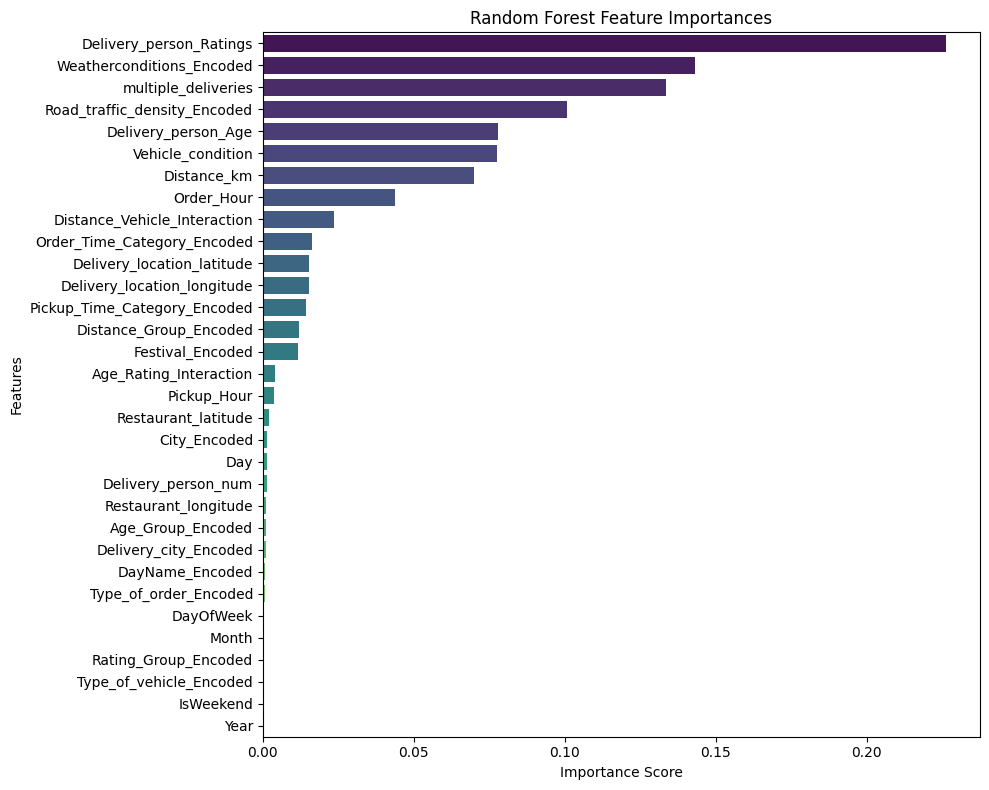

In [36]:
plt.figure(figsize=(10, 8))

# Plot
sns.barplot(
    x=features['coef_value'],
    y=features.index,
    palette='viridis'
)

# Titles and labels
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

Generates a bar chart comparing the test R² scores of all models. The bars are sorted from highest to lowest R². The top three models are highlighted with a different color (#E9C46A). Each bar is annotated with the exact R² value.



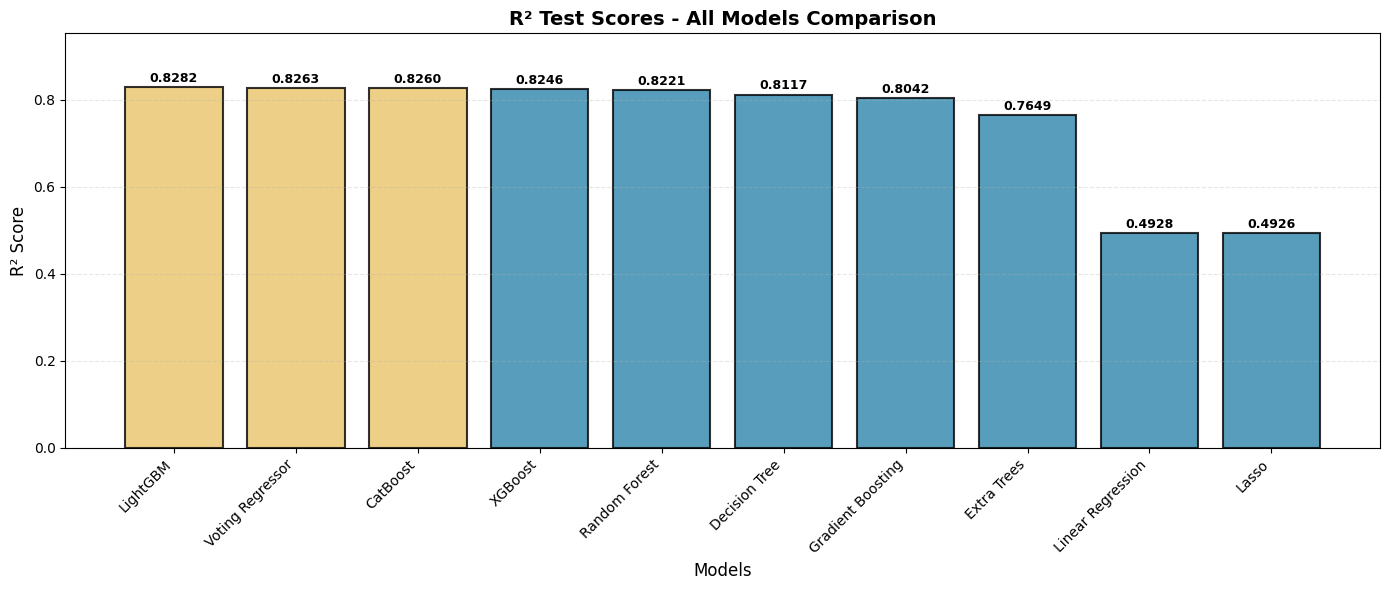

In [37]:

models_list = list(all_model_metrics.keys())
r2_test = [all_model_metrics[model]['R2_Test'] for model in models_list]
rmse_test = [all_model_metrics[model]['RMSE_Test'] for model in models_list]
mse_test = [all_model_metrics[model]['MSE_Test'] for model in models_list]

# 1. Bar Plot: R² Test Scores Only
plt.figure(figsize=(14, 6))

# Sort by R² score for better visualization
sorted_indices = np.argsort(r2_test)[::-1]
models_sorted = [models_list[i] for i in sorted_indices]
r2_sorted = [r2_test[i] for i in sorted_indices]

colors = ['#2E86AB'] * len(models_sorted)
for i in range(min(3, len(colors))):
    colors[i] = '#E9C46A'

bars = plt.bar(models_sorted, r2_sorted, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

plt.xlabel('Models', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('R² Test Scores - All Models Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.ylim(0, max(r2_sorted) * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Generates a bar chart comparing the test RMSE scores. Since lower RMSE is better, the bars are sorted in ascending order. The three best (lowest RMSE) models are highlighted with a different color. Annotations show the RMSE values.

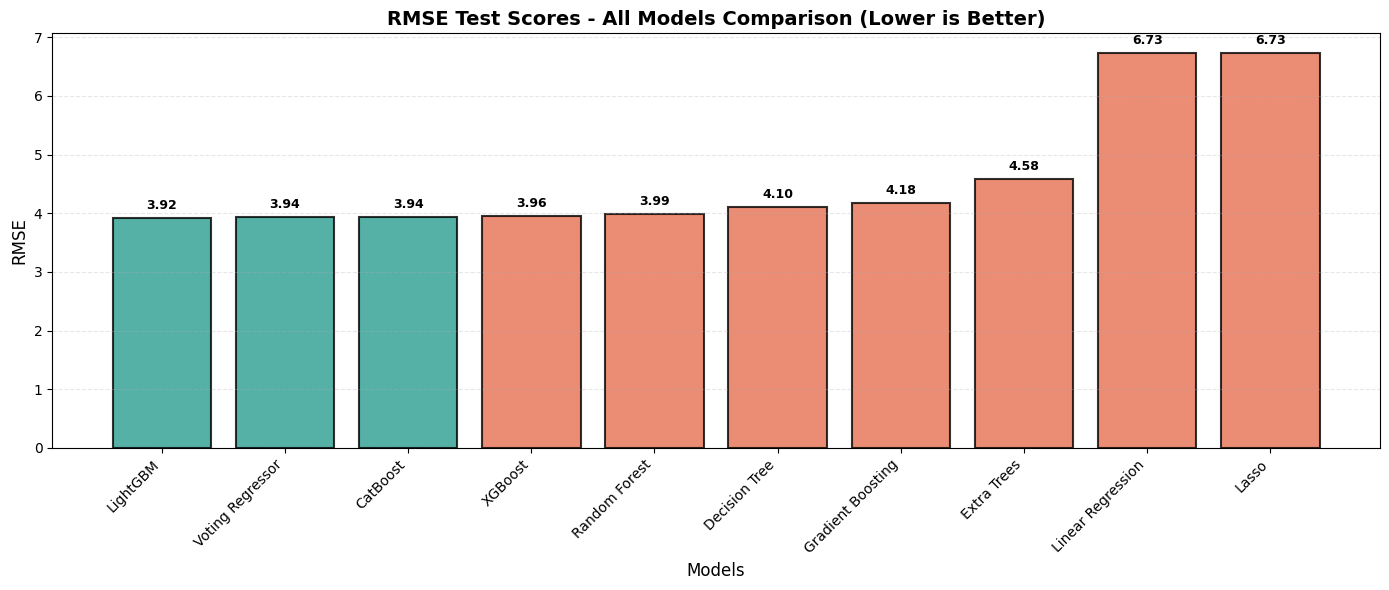

In [38]:
# 2. Bar Plot: RMSE Test Scores Only (Lower is Better)
plt.figure(figsize=(14, 6))

# Sort by RMSE score (ascending - lower is better)
sorted_indices = np.argsort(rmse_test)
models_sorted_rmse = [models_list[i] for i in sorted_indices]
rmse_sorted = [rmse_test[i] for i in sorted_indices]


colors = ['#E76F51'] * len(models_sorted_rmse)
for i in range(min(3, len(colors))):
    colors[i] = '#2A9D8F'

bars = plt.bar(models_sorted_rmse, rmse_sorted, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

plt.xlabel('Models', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('RMSE Test Scores - All Models Comparison (Lower is Better)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Creates a side‑by‑side horizontal bar chart showing both R² (left) and RMSE (right) for all models, sorted alphabetically. This allows easy comparison of both metrics simultaneously. The R² bars are blue, RMSE bars are red. Annotations provide exact values.

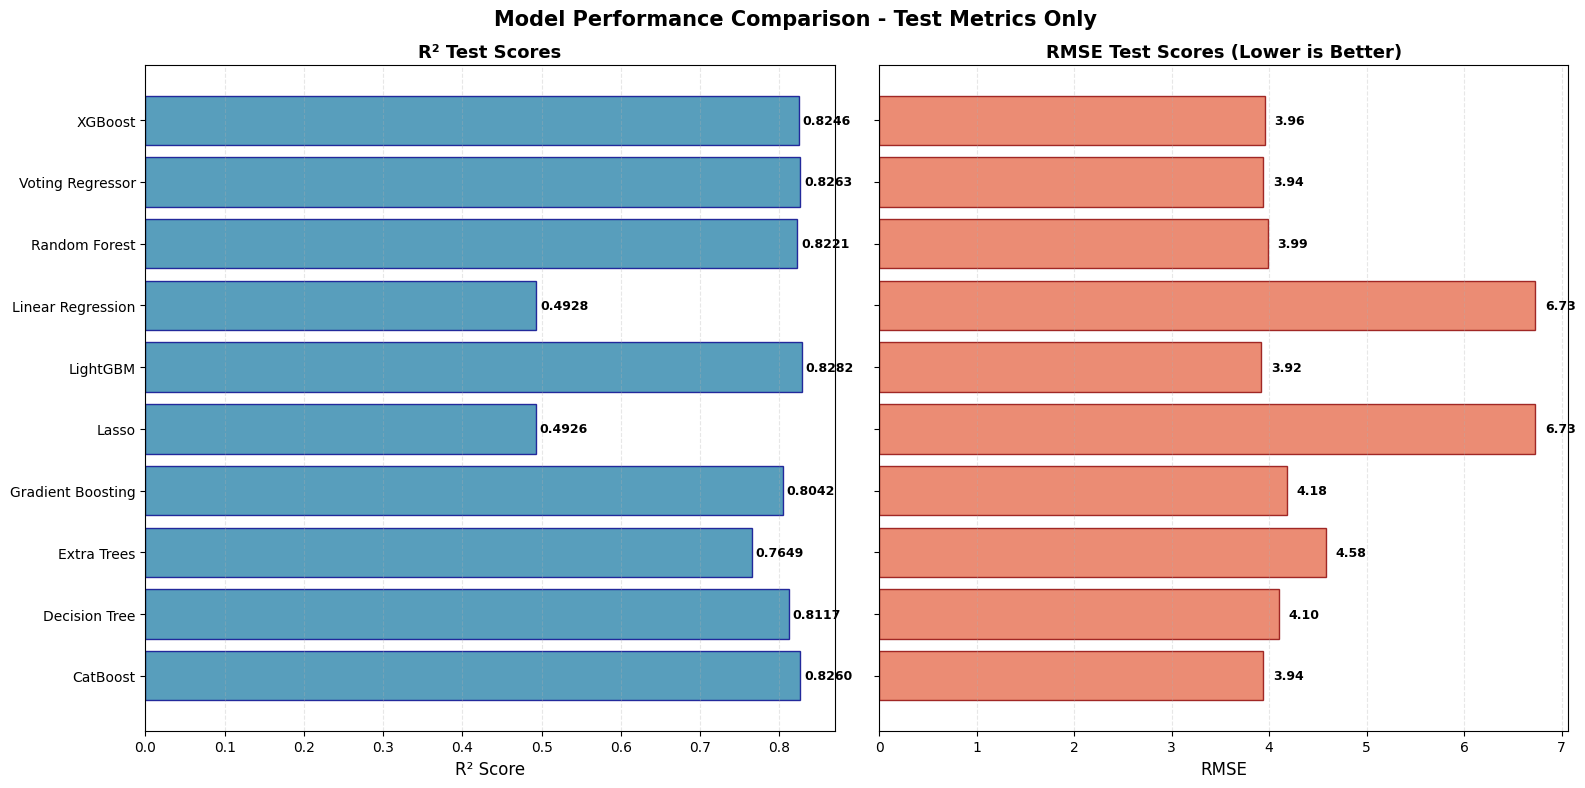

In [39]:
# 3. Combined Horizontal Bar Chart - R² and RMSE Side by Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Sort models alphabetically for consistency
models_sorted_alpha = sorted(models_list)
r2_alpha = [all_model_metrics[model]['R2_Test'] for model in models_sorted_alpha]
rmse_alpha = [all_model_metrics[model]['RMSE_Test'] for model in models_sorted_alpha]

y_pos = np.arange(len(models_sorted_alpha))

bars1 = ax1.barh(y_pos, r2_alpha, color='#2E86AB', alpha=0.8, edgecolor='darkblue')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(models_sorted_alpha, fontsize=10)
ax1.set_xlabel('R² Score', fontsize=12)
ax1.set_title('R² Test Scores', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--', axis='x')

for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

bars2 = ax2.barh(y_pos, rmse_alpha, color='#E76F51', alpha=0.8, edgecolor='darkred')
ax2.set_yticks(y_pos)
ax2.set_yticklabels([])
ax2.set_xlabel('RMSE', fontsize=12)
ax2.set_title('RMSE Test Scores (Lower is Better)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--', axis='x')

for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison - Test Metrics Only', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()